In [1]:
import numpy as np

# Simulate 500 applicant ages (assume ages follow a normal distribution)
applicant_ages = np.random.normal(loc=35, scale=10, size=500)

# Simulate loan amounts (positively skewed, so use exponential)
loan_amounts = np.random.exponential(scale=15000, size=500)

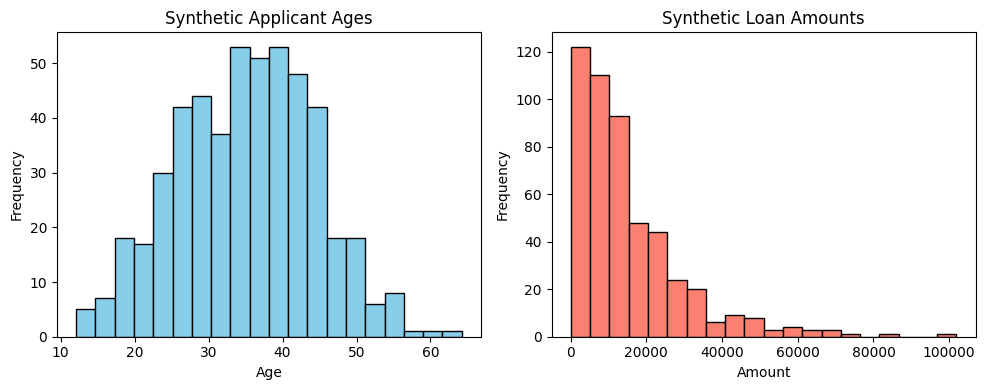

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Age distribution
axes[0].hist(applicant_ages, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Synthetic Applicant Ages')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Loan amount distribution
axes[1].hist(loan_amounts, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Synthetic Loan Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig("applicant_ages.png")

In [3]:
import pandas as pd

# Simulated real applicant data
data = pd.DataFrame({
    'credit_score': [720, 690, 680, 710, 740],
    'loan_purpose': ['auto', 'home', 'education', 'business', 'personal']
})

# Create a bootstrap sample of 10 applicants
bootstrap_sample = data.sample(n=10, replace=True)

In [4]:
data

,credit_score,loan_purpose
0,720,auto
1,690,home
2,680,education
3,710,business
4,740,personal


In [5]:
bootstrap_sample

,credit_score,loan_purpose
3,710,business
3,710,business
2,680,education
3,710,business
4,740,personal
3,710,business
1,690,home
2,680,education
2,680,education
2,680,education


In [6]:
# Shuffle loan purposes only
shuffled_purposes = data['loan_purpose'].sample(frac=1).reset_index(drop=True)

In [7]:
# Simulate variation in monthly income by injecting noise
base_income = np.array([4000, 4500, 4800, 5200, 6000])
noisy_income = base_income + np.random.normal(loc=0, scale=300, size=len(base_income))

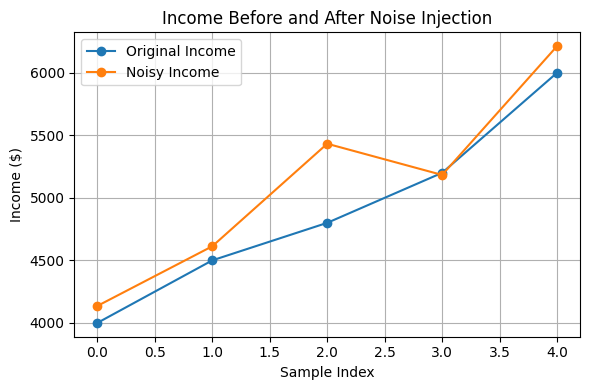

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(base_income, label='Original Income', marker='o')
plt.plot(noisy_income, label='Noisy Income', marker='o')
plt.title('Income Before and After Noise Injection')
plt.xlabel('Sample Index')
plt.ylabel('Income ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('noise_injection.png')

In [9]:
from faker import Faker
import numpy as np
import random
import pandas as pd

fake = Faker()
customers = []

for _ in range(10):
    age = random.randint(20, 75)
    income = round(np.random.normal(loc=50000 + age * 300, scale=5000), 2)
    premium = round(income * random.uniform(0.05, 0.15), 2)

    customer = {
        'name': fake.name(),
        'email': fake.email(),
        'age': age,
        'annual_income': income,
        'policy_type': random.choice(['health', 'auto', 'home']),
        'premium_estimate': premium
    }
    customers.append(customer)

df = pd.DataFrame(customers)
df

ModuleNotFoundError: No module named 'faker'

## Section 3 : Probabilistic

In [15]:
import pandas as pd
import numpy as np
from copulas.multivariate import GaussianMultivariate

# Sample real dataset (could be anonymized or simulated)
real_data = pd.DataFrame({
    'age': np.random.normal(40, 10, 500),
    'income': np.random.normal(60000, 15000, 500),
    'credit_score': np.random.normal(700, 50, 500)
})

# Fit the Gaussian copula model
model = GaussianMultivariate()
model.fit(real_data)

# Generate synthetic data
synthetic_data = model.sample(500)

# Compare correlation structure
print("Real Data Correlation:\n", real_data.corr())
print("\nSynthetic Data Correlation:\n", synthetic_data.corr())


Real Data Correlation:
                    age    income  credit_score
age           1.000000  0.041055     -0.008046
income        0.041055  1.000000     -0.000858
credit_score -0.008046 -0.000858      1.000000

Synthetic Data Correlation:
                    age    income  credit_score
age           1.000000  0.025237     -0.089715
income        0.025237  1.000000     -0.040345
credit_score -0.089715 -0.040345      1.000000


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Real data correlation matrix
sns.heatmap(real_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix: Real Data')

# Synthetic data correlation matrix
sns.heatmap(synthetic_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix: Synthetic Data')

plt.tight_layout()
plt.savefig("copula_correlation_comparison.png", dpi=300, bbox_inches='tight')
plt.close()


In [18]:
real_data.head()

,age,income,credit_score
0,36.077721,71640.211568,715.873505
1,26.786082,40225.480066,676.088861
2,44.035277,59047.160097,674.757067
3,34.230026,38168.102360,732.392868
4,37.910924,60933.971525,746.439452


In [19]:
synthetic_data.head()

,age,income,credit_score
0,34.892386,38506.004187,698.772814
1,30.064641,44136.148141,777.300643
2,42.914657,55734.505327,723.012835
3,18.069558,51534.975215,709.538114
4,31.847798,93483.291816,796.526604


## ML BAsed

In [24]:
import pandas as pd

# Column names from adult.names file
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

# Load the original adult.data file
data = pd.read_csv("adult.data", names=column_names, na_values=" ?", skipinitialspace=True)
data.to_csv("adult_census.csv", index=False)